# 04 — Preprocessing

Notebook ini menyiapkan data hasil feature engineering untuk pelatihan model: encoding kategorikal, train-test split, dan scaling fitur.

## Input
- `data/df_feat.csv` — keluaran dari `03_feature_engineering.ipynb` (1,047,135 baris × 103 kolom)

## Output
- `data/processed/X_train.csv`, `X_test.csv` — fitur train/test (98 kolom)
- `data/processed/y_train.csv`, `y_test.csv` — target AQI
- `data/processed/df_train_datetime.csv`, `df_test_datetime.csv` — timestamp untuk evaluasi
- `artifacts/robust_scaler.pkl` — scaler yang di-fit pada train set
- `artifacts/label_encoder_city.pkl` — encoder kota
- `artifacts/feature_list.json` — daftar 98 fitur

## Langkah Utama
1. **Label Encoding** `city_name` → `city_encoded` (30 kota)
2. **One-Hot Encoding** `period_of_day` dan `season`
3. **Definisi fitur**: 98 kolom — raw polutan waktu *t* dikecualikan untuk mencegah data leakage
4. **Time-Aware Split**: 80% train (Jan 2000–Jan 2025) / 20% test (Jan–Nov 2025)
5. **RobustScaler**: di-*fit* hanya pada train set, lalu di-*transform* ke keduanya

**Prasyarat:** Jalankan `03_feature_engineering.ipynb` terlebih dahulu.
**Notebook berikutnya:** `05_modelling.ipynb`

### 6.1 Encoding Fitur Kategorikal

In [1]:
# === SEL INISIALISASI ===
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, LabelEncoder

df_feat = pd.read_csv('data/df_feat.csv', parse_dates=['datetime'])
print(f"df_feat dimuat: {df_feat.shape}")

df_feat dimuat: (1047135, 103)


In [2]:
df_proc = df_feat.copy()

# === city_name: Label Encoding (banyak kota, LabelEncoding lebih efisien)
le_city = LabelEncoder()
df_proc['city_encoded'] = le_city.fit_transform(df_proc['city_name'])
city_mapping = dict(zip(le_city.classes_, le_city.transform(le_city.classes_)))
print('City Encoding Mapping:')
print(city_mapping)

# === period_of_day: One-Hot Encoding
df_proc = pd.get_dummies(df_proc, columns=['period_of_day'], prefix='pod', dtype=int)

# === season: One-Hot Encoding
df_proc = pd.get_dummies(df_proc, columns=['season'], prefix='season', dtype=int)

print(f'\n✅ Encoding selesai. Shape: {df_proc.shape}')

City Encoding Mapping:
{'Azimpur': np.int64(0), 'Badarganj': np.int64(1), 'Baniachang': np.int64(2), 'Barisāl': np.int64(3), 'Bera': np.int64(4), 'Bhairab Bāzār': np.int64(5), 'Bherāmāra': np.int64(6), 'Bhola': np.int64(7), 'Bhāndāria': np.int64(8), 'Bhātpāra Abhaynagar': np.int64(9), 'Bogra': np.int64(10), 'Burhānuddin': np.int64(11), 'Bājitpur': np.int64(12), 'Bāndarban': np.int64(13), 'Char Bhadrāsan': np.int64(14), 'Chhāgalnāiya': np.int64(15), 'Chhātak': np.int64(16), 'Chilmāri': np.int64(17), 'Chittagong': np.int64(18), 'Comilla': np.int64(19), 'Cox’s Bāzār': np.int64(20), 'Dhaka': np.int64(21), 'Dinājpur': np.int64(22), 'Dohār': np.int64(23), 'Farīdpur': np.int64(24), 'Fatikchari': np.int64(25), 'Feni': np.int64(26), 'Gafargaon': np.int64(27), 'Gaibandha': np.int64(28), 'Gaurnadi': np.int64(29)}

✅ Encoding selesai. Shape: (1047135, 110)


### 6.2 Definisi Kolom yang Digunakan untuk Modelling

In [3]:
# Kolom yang tidak masuk ke model
COLS_TO_EXCLUDE = [
    'datetime',       # sudah diekstrak sebagai fitur temporal
    'city_id',        # digantikan city_encoded
    'city_name',      # digantikan city_encoded
    'lat', 'lon',     # konstan per kota, sudah diwakilkan city_encoded
    'aqi',            # TARGET — tidak boleh menjadi fitur
    # MENCEGAH DATA LEAKAGE: raw polutan waktu t tidak tersedia saat prediksi real-time.
    # Nilai polutan jam ini belum diketahui — kita hanya punya nilai jam sebelumnya (lag).
    'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone',
    # Catatan: pm_ratio_lag1, pm_total_lag1, oxidant_load_lag1, combustion_idx_lag1
    # SENGAJA tidak dikecualikan — mereka berbasis lag-1 (nilai t-1), bukan nilai t,
    # sehingga aman digunakan sebagai fitur prediksi tanpa menyebabkan data leakage.
]

TARGET = 'aqi'
FEATURES = [c for c in df_proc.columns if c not in COLS_TO_EXCLUDE]

print(f'Target   : {TARGET}')
print(f'Jumlah fitur: {len(FEATURES)}')
print(f'\nDaftar fitur:')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:3d}. {f}')

Target   : aqi
Jumlah fitur: 98

Daftar fitur:
    1. hour
    2. day
    3. month
    4. year
    5. dayofweek
    6. dayofyear
    7. quarter
    8. weekofyear
    9. is_weekend
   10. hour_sin
   11. hour_cos
   12. month_sin
   13. month_cos
   14. dow_sin
   15. dow_cos
   16. pm10_lag1
   17. pm10_lag3
   18. pm10_lag6
   19. pm10_lag24
   20. pm10_roll3m
   21. pm10_roll3std
   22. pm10_roll6m
   23. pm10_roll6std
   24. pm10_roll24m
   25. pm10_roll24std
   26. pm2_5_lag1
   27. pm2_5_lag3
   28. pm2_5_lag6
   29. pm2_5_lag24
   30. pm2_5_roll3m
   31. pm2_5_roll3std
   32. pm2_5_roll6m
   33. pm2_5_roll6std
   34. pm2_5_roll24m
   35. pm2_5_roll24std
   36. carbon_monoxide_lag1
   37. carbon_monoxide_lag3
   38. carbon_monoxide_lag6
   39. carbon_monoxide_lag24
   40. carbon_monoxide_roll3m
   41. carbon_monoxide_roll3std
   42. carbon_monoxide_roll6m
   43. carbon_monoxide_roll6std
   44. carbon_monoxide_roll24m
   45. carbon_monoxide_roll24std
   46. nitrogen_dioxide_lag1
  

### 6.3 Train-Test Split (Time-Aware)

In [4]:
# PENTING: Untuk time-series, split HARUS berdasarkan waktu, bukan random
# Gunakan 80% awal untuk train, 20% akhir untuk test

df_sorted = df_proc.sort_values('datetime').reset_index(drop=True)
split_idx = int(len(df_sorted) * 0.8)

split_date = df_sorted.iloc[split_idx]['datetime']
df_train = df_sorted[df_sorted['datetime'] < split_date].copy()
df_test  = df_sorted[df_sorted['datetime'] >= split_date].copy()

X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test  = df_test[FEATURES]
y_test  = df_test[TARGET]

print('=== Time-Aware Train-Test Split ===')
print(f'Train: {X_train.shape[0]:,} baris  ({df_train["datetime"].min().date()} → {df_train["datetime"].max().date()})')
print(f'Test : {X_test.shape[0]:,} baris  ({df_test["datetime"].min().date()} → {df_test["datetime"].max().date()})')
print(f'Ratio: {X_train.shape[0]/len(df_sorted)*100:.1f}% / {X_test.shape[0]/len(df_sorted)*100:.1f}%')

=== Time-Aware Train-Test Split ===
Train: 837,697 baris  (2000-01-02 → 2025-01-27)
Test : 209,438 baris  (2025-01-27 → 2025-11-23)
Ratio: 80.0% / 20.0%


### 6.4 Scaling Fitur (RobustScaler)

In [5]:
# Gunakan RobustScaler karena data polutan seringkali memiliki skewness tinggi
# RobustScaler menggunakan median & IQR, lebih tahan terhadap outlier dibanding StandardScaler

# Kolom binary/one-hot tidak perlu di-scale
binary_cols = [c for c in FEATURES if df_proc[c].nunique() == 2]
target_leak_cols = [c for c in FEATURES if c.startswith('aqi_lag') or c.startswith('aqi_roll')]
scale_cols  = [c for c in FEATURES if c not in binary_cols and c not in target_leak_cols]

print(f'Kolom yang di-scale : {len(scale_cols)}')
print(f'Kolom binary (skip) : {len(binary_cols)} → {binary_cols}')
print(f'Kolom target leak (skip) : {len(target_leak_cols)} → {target_leak_cols}')

scaler = RobustScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

# Fit HANYA pada train, transform keduanya
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols]  = scaler.transform(X_test[scale_cols])

print(f'\n✅ Scaling selesai')
print(f'   X_train_scaled: {X_train_scaled.shape}')
print(f'   X_test_scaled : {X_test_scaled.shape}')

Kolom yang di-scale : 79
Kolom binary (skip) : 9 → ['is_weekend', 'pod_afternoon', 'pod_evening', 'pod_morning', 'pod_night', 'season_monsoon', 'season_post_monsoon', 'season_pre_monsoon', 'season_winter']
Kolom target leak (skip) : 10 → ['aqi_lag1', 'aqi_lag3', 'aqi_lag6', 'aqi_lag24', 'aqi_roll3m', 'aqi_roll3std', 'aqi_roll6m', 'aqi_roll6std', 'aqi_roll24m', 'aqi_roll24std']

✅ Scaling selesai
   X_train_scaled: (837697, 98)
   X_test_scaled : (209438, 98)


### 6.5 Validasi Akhir Preprocessing

=== VALIDASI AKHIR ===
Missing value di X_train: 0
Missing value di X_test : 0
Missing value di y_train: 0
Missing value di y_test : 0

=== STATISTIK TARGET ===
y_train - min: 9.00, max: 299.60, mean: 119.20
y_test  - min: 11.00, max: 244.00, mean: 98.82


C:\Users\faizn\AppData\Local\Temp\ipykernel_17888\2070038111.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([y_train, y_test], labels=['Train', 'Test'], patch_artist=True,


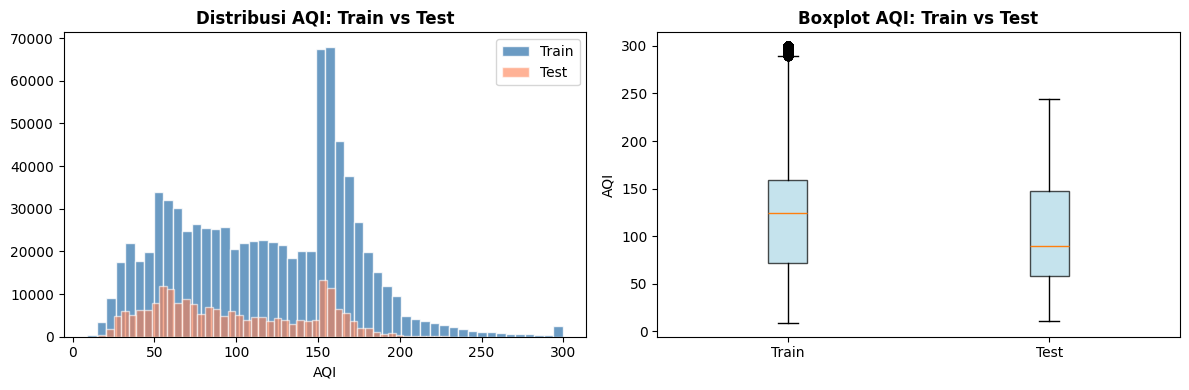

In [6]:
print('=== VALIDASI AKHIR ===')
print(f'Missing value di X_train: {X_train_scaled.isnull().sum().sum()}')
print(f'Missing value di X_test : {X_test_scaled.isnull().sum().sum()}')
print(f'Missing value di y_train: {y_train.isnull().sum()}')
print(f'Missing value di y_test : {y_test.isnull().sum()}')

print(f'\n=== STATISTIK TARGET ===')
print(f'y_train - min: {y_train.min():.2f}, max: {y_train.max():.2f}, mean: {y_train.mean():.2f}')
print(f'y_test  - min: {y_test.min():.2f}, max: {y_test.max():.2f}, mean: {y_test.mean():.2f}')

# Distribusi target train vs test
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=50, color='steelblue', edgecolor='white', alpha=0.8, label='Train')
axes[0].hist(y_test,  bins=50, color='coral',     edgecolor='white', alpha=0.6, label='Test')
axes[0].set_title('Distribusi AQI: Train vs Test', fontweight='bold')
axes[0].set_xlabel('AQI')
axes[0].legend()

axes[1].boxplot([y_train, y_test], labels=['Train', 'Test'], patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[1].set_title('Boxplot AQI: Train vs Test', fontweight='bold')
axes[1].set_ylabel('AQI')

plt.tight_layout()
plt.show()

---
## 7. Export Data Siap Modelling

In [7]:
# === RINGKASAN PIPELINE ===
print('=' * 60)
print('RINGKASAN PIPELINE PREPROCESSING')
print('=' * 60)
print(f'Dataset dimuat      : {df_feat.shape[0]:,} baris x {df_feat.shape[1]} kolom')
print(f'Dataset final train : {X_train_scaled.shape[0]:,} baris x {X_train_scaled.shape[1]} kolom')
print(f'Dataset final test  : {X_test_scaled.shape[0]:,} baris x {X_test_scaled.shape[1]} kolom')
print(f'Jumlah fitur        : {len(FEATURES)}')
print(f'Target              : {TARGET}')
print()
print('LANGKAH YANG DILAKUKAN:')
print('  1. Parse datetime & sort per kota')
print('  2. Hapus duplikasi (city_id + datetime)')
print('  3. Konversi nilai negatif -> NaN')
print('  4. Winsorizing (1%-99%) per kota')
print('  5. Drop carbon_dioxide (>74% missing)')
print('  6. Drop baris AQI missing (target)')
print('  7. Interpolasi linear per kota (fitur)')
print('  8. Feature engineering temporal (cyclical)')
print('  9. Lag & rolling features (1,3,6,24 jam)')
print(' 10. Fitur interaksi polutan')
print(' 11. Label Encoding (city) + One-Hot (period, season)')
print(' 12. Time-aware split (80/20)')
print(' 13. RobustScaler (fit train only)')
print('=' * 60)
print('Data siap untuk modelling!')

RINGKASAN PIPELINE PREPROCESSING
Dataset dimuat      : 1,047,135 baris x 103 kolom
Dataset final train : 837,697 baris x 98 kolom
Dataset final test  : 209,438 baris x 98 kolom
Jumlah fitur        : 98
Target              : aqi

LANGKAH YANG DILAKUKAN:
  1. Parse datetime & sort per kota
  2. Hapus duplikasi (city_id + datetime)
  3. Konversi nilai negatif -> NaN
  4. Winsorizing (1%-99%) per kota
  5. Drop carbon_dioxide (>74% missing)
  6. Drop baris AQI missing (target)
  7. Interpolasi linear per kota (fitur)
  8. Feature engineering temporal (cyclical)
  9. Lag & rolling features (1,3,6,24 jam)
 10. Fitur interaksi polutan
 11. Label Encoding (city) + One-Hot (period, season)
 12. Time-aware split (80/20)
 13. RobustScaler (fit train only)
Data siap untuk modelling!


---
## 8. Modelling

Tahapan berikutnya adalah modelling di `05_modelling.ipynb`, menggunakan:
1. Baseline Model (Naive & Rolling Mean 24h)
2. **LightGBM Regressor** (model utama, histogram-based gradient boosting + early stopping)

In [8]:
# === SIMPAN HASIL PREPROCESSING ===
import joblib, json
os.makedirs('data/processed', exist_ok=True)
os.makedirs('artifacts', exist_ok=True)

X_train_scaled.to_csv('data/processed/X_train.csv', chunksize=10000, index=False)
X_test_scaled.to_csv('data/processed/X_test.csv', chunksize=10000,  index=False)
y_train.to_csv('data/processed/y_train.csv', chunksize=10000, index=False)
y_test.to_csv('data/processed/y_test.csv', chunksize=10000,   index=False)
df_train[['datetime']].to_csv('data/processed/df_train_datetime.csv', chunksize=10000, index=False)
df_test[['datetime']].to_csv('data/processed/df_test_datetime.csv', chunksize=10000,  index=False)

joblib.dump(scaler,  'artifacts/robust_scaler.pkl')
joblib.dump(le_city, 'artifacts/label_encoder_city.pkl')
json.dump(FEATURES,  open('artifacts/feature_list.json', 'w'))

print("Semua artefak preprocessing berhasil disimpan.")

Semua artefak preprocessing berhasil disimpan.
